# Final Results Summary

This notebook finds the most recent `final_results.json` under the `runs/` folder, extracts `train_error`, `test_error`, and `pac_bayes_error_bound`, then displays them in a table and a bar plot.

In [7]:
import os
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use('seaborn-v0_8')

In [8]:
def find_latest_final_results(root_dir='runs'):
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f'results root not found: {root_dir}')

    candidates = list(root.rglob('final_results.json'))
    if len(candidates) == 0:
        raise FileNotFoundError(f'No final_results.json found under {root_dir}')

    # pick the most recently modified file
    latest = max(candidates, key=lambda p: p.stat().st_mtime)
    return latest

In [9]:
# Locate and load the latest final_results.json
try:
    results_path = find_latest_final_results('runs')
    print('Using:', results_path)
    with open(results_path, 'r') as f:
        results = json.load(f)
except Exception as e:
    raise

Using: runs/20260427_105024_fmnist/final_results.json


In [10]:
# Extract desired metrics with safe fallbacks
def get_metric(d, keys):
    for k in keys:
        if k in d:
            return d[k]
    return None

train_error = get_metric(results, ['train_error', 'train_error'])
test_error = get_metric(results, ['test_error', 'test_error'])
pac_bayes_error_bound = get_metric(results, ['pac_bayes_error_bound', 'pac_bayes_bound'])

metrics = {
    'train_error': train_error,
    'test_error': test_error,
    'pac_bayes_error_bound': pac_bayes_error_bound,
}
df = pd.DataFrame([metrics])
df.index = ['final']

display(df)

,train_error,test_error,pac_bayes_error_bound
final,0.096067,0.1247,0.262891


Saved plot to: runs/20260427_105024_fmnist/final_results_summary.png


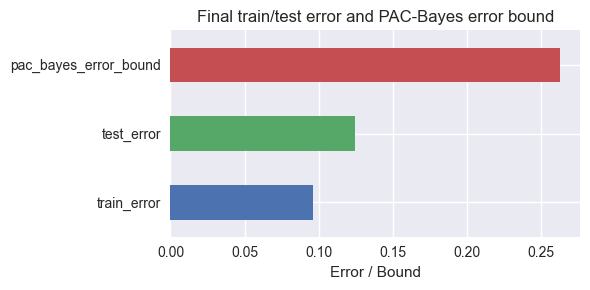

In [6]:
# Plot the three values as a horizontal bar chart
fig, ax = plt.subplots(figsize=(6, 3))
plot_df = df.T.rename(columns={ 'final': 'value' })
plot_df['value'] = plot_df['value'].astype(float)
plot_df.plot.barh(y='value', legend=False, ax=ax, color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_xlabel('Error / Bound')
ax.set_title('Final train/test error and PAC-Bayes error bound')
plt.tight_layout()
# Save figure next to the results file for convenience
out_png = Path(results_path).with_name('final_results_summary.png')
fig.savefig(out_png, dpi=200)
print(f'Saved plot to: {out_png}')
plt.show()

**Notes**: If you want to analyze a specific run, pass its run folder or the full path to `final_results.json`.
You can re-run the first cell after changing the `find_latest_final_results` argument.